In [400]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy import io, signal
import os

plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams.update({'font.size': 18})

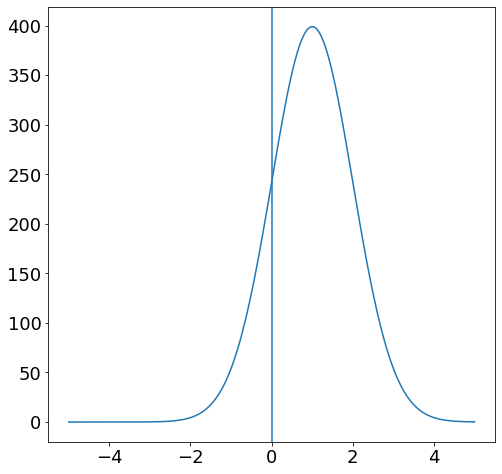

In [405]:
# Intensity is Gaussian with position, and maximum linearly shifts with time
J = lambda u,t: 1000 * (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((u - 1 + 0.1 * t) / 1) ** 2) 
u = -1
y0 = J(u,0)

uvals = np.linspace(-5, 5, 200)
plt.plot(uvals, J(uvals, 0))
plt.axvline(0)
plt.show()

In [402]:
## Extremum Seeking Control Parameters
freq = 10*2*np.pi # sample frequency
dt = 1/freq
T = 100 # total period of simulation (in seconds)
A = 0.07 # amplitude
omega = 10*2*np.pi # 10 Hz
phase = 0
K = 0.1 # Integration gain

In [403]:
## using lfilter
## High pass filter (Butterworth filter)
butterorder = 1
butterfreq = 2 # in Hz
butterfreq = butterfreq/(freq/2) # normalize to Nyquist frequency

b,a = signal.butter(butterorder, butterfreq, btype='highpass')

ys = np.zeros(butterorder+1)+y0  # Initial samples
HPF = np.zeros(butterorder+1)  # Initial filtered samples

uhat = u
yvals = np.zeros(int(T/dt))
uhats = np.zeros_like(yvals)
uvals = np.zeros_like(yvals)

z = signal.lfilter_zi(b, a)  # Initial filter delays

for i in range(int(T/dt)):
    t = i * dt
#     yvals[i] = J(u, t)
    # noisy measurement
    yvals[i] = np.random.poisson(J(u, t))
    
    # Shift samples by one
    for k in range(butterorder):
        ys[k] = ys[k+1]
        
    ys[butterorder] = yvals[i]
    
    # Low pass filter
    HPF, z = signal.lfilter(b, a, ys, zi=z)
    
    HPFnew = HPF[1]
    
    # Calculate reference 
    xi = HPFnew * np.sin(omega * t + phase)
    
    # Calculate control signal
    uhat = uhat + xi * K * dt
    
    # Apply constant oscillation to control signal
    u = uhat + A * np.sin(omega * t + phase)
    
    uhats[i] = uhat
    uvals[i] = u

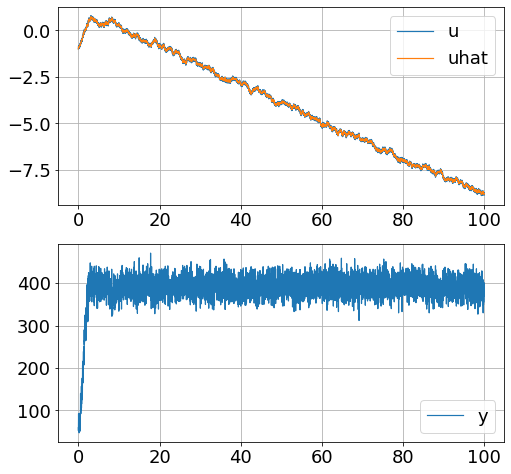

In [404]:
## Figures
tspan = dt*np.arange(int(T/dt))
fig,axs = plt.subplots(2,1)
axs[0].plot(tspan,uvals,linewidth=1.2,label='u')
axs[0].plot(tspan,uhats,linewidth=1.2,label='uhat')
axs[0].legend()
axs[0].grid()

axs[1].plot(tspan,yvals,linewidth=1.2, label='y')
axs[1].grid()
# axs[1].set_ylim(-1,2)
axs[1].legend()

plt.show()